# **Data Mining UAS: NETFLIX DATASET**

**Langkah 0: Upload Data**

In [2]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Netflix Datasets Evaluation MS Excel.csv")
df.head()

Saving Netflix Datasets Evaluation MS Excel.csv to Netflix Datasets Evaluation MS Excel.csv


,show_id,type,title,director,cast,country,date_added,date_added.1,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",25-09-2021,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",24-09-2021,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",24-09-2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",24-09-2021,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",24-09-2021,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Mengimpor semua library yang diperlukan dan memuat dataset.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files, drive

# --- 0.1 Memuat Dataset ---
# Pilihan 1: Unggah file secara langsung ke sesi Colab (sementara)
# Jika file sudah ada di Google Drive Anda, Anda bisa mengomentari bagian ini
# dan langsung ke Pilihan 2.
try:
    print("Mengunggah file CSV...")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0] # Ambil nama file yang diunggah
    print(f"File '{file_name}' berhasil diunggah.")
    df = pd.read_csv(file_name)
except Exception as e:
    print(f"Gagal mengunggah file: {e}")
    print("Mencoba memuat dari Google Drive (pastikan sudah dimount dan path benar)...")
    # Pilihan 2: Muat dari Google Drive (Direkomendasikan untuk permanen)
    try:
        drive.mount('/content/drive')
        # Sesuaikan path jika file Anda di lokasi lain di Google Drive
        file_name = "Netflix Datasets Evaluation MS Excel.csv" # Nama file yang diharapkan
        file_path_drive = f'/content/drive/MyDrive/{file_name}'
        df = pd.read_csv(file_path_drive)
        print(f"File '{file_path_drive}' berhasil dimuat dari Google Drive.")
    except Exception as e_drive:
        print(f"Gagal memuat dari Google Drive: {e_drive}")
        print("Pastikan file 'Netflix Datasets Evaluation MS Excel.csv' ada di lokasi yang benar di Google Drive.")
        df = None

if df is None:
    print("\nERROR: Tidak dapat melanjutkan karena dataset tidak berhasil dimuat.")
    exit() # Hentikan eksekusi jika dataset tidak bisa dimuat

print("\n--- 0.2 DataFrame Asli (5 Baris Pertama) ---")
print(df.head())
print("\n--- 0.3 Informasi Umum DataFrame Asli ---")
df.info()

Mengunggah file CSV...


Saving Netflix Datasets Evaluation MS Excel.csv to Netflix Datasets Evaluation MS Excel (9).csv
File 'Netflix Datasets Evaluation MS Excel (9).csv' berhasil diunggah.

--- 0.2 DataFrame Asli (5 Baris Pertama) ---
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...       

**Langkah 1: Eksplorasi Data Keseluruhan**

Melakukan analisis awal dan visualisasi pada dataset penuh.


LANGKAH 1: EKSPLORASI DATA KESELURUHAN

--- 1.1 Missing Values (Keseluruhan Dataset) ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
date_added.1      10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

--- 1.2 Statistik Deskriptif ---
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8804           4528                7692   
top      s8807  Movie  Feb-09  Rajiv Chilaka  David Attenborough   
freq         1   6131       2             19                  19   
mean       NaN    NaN     NaN            NaN                 NaN   
std        NaN    NaN     NaN            NaN                 NaN   
min        NaN    NaN     NaN            NaN                 NaN   
25%        NaN    NaN     NaN            NaN  

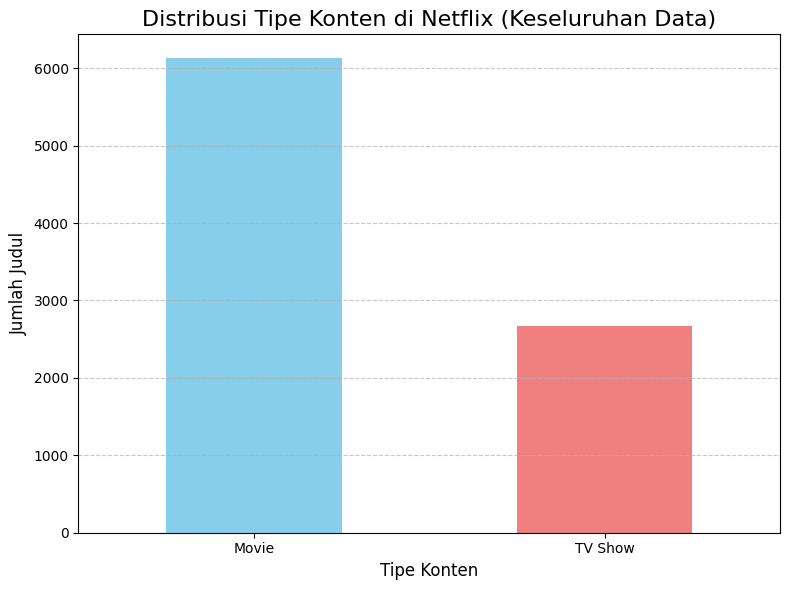

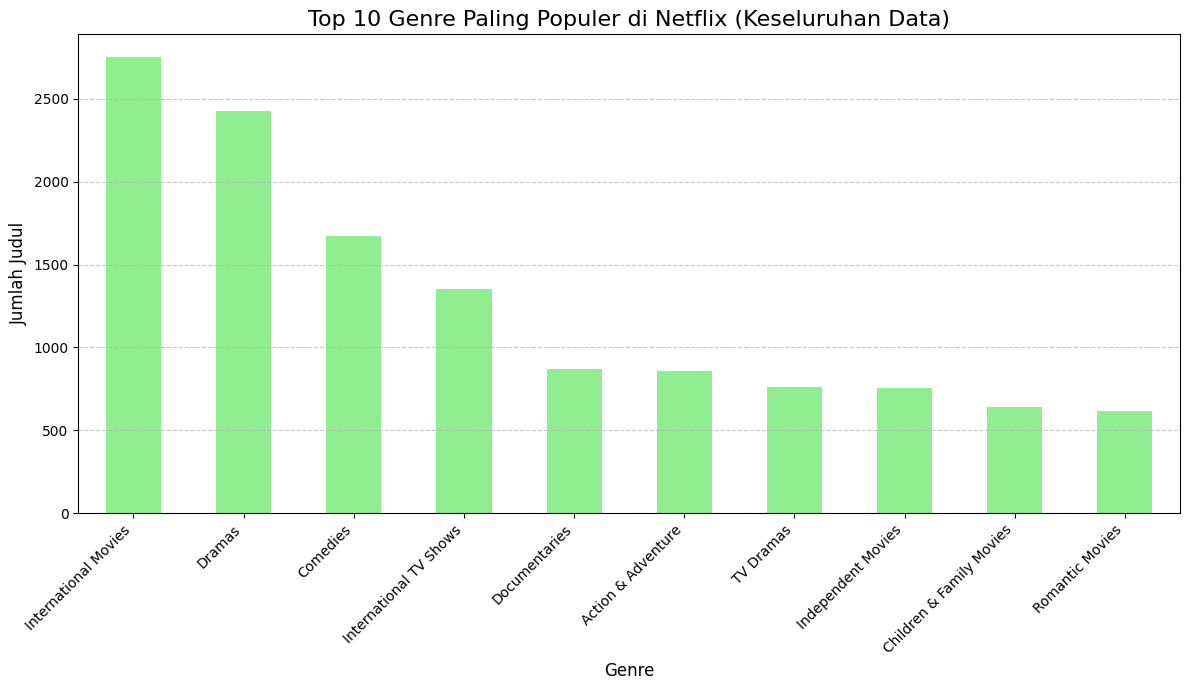

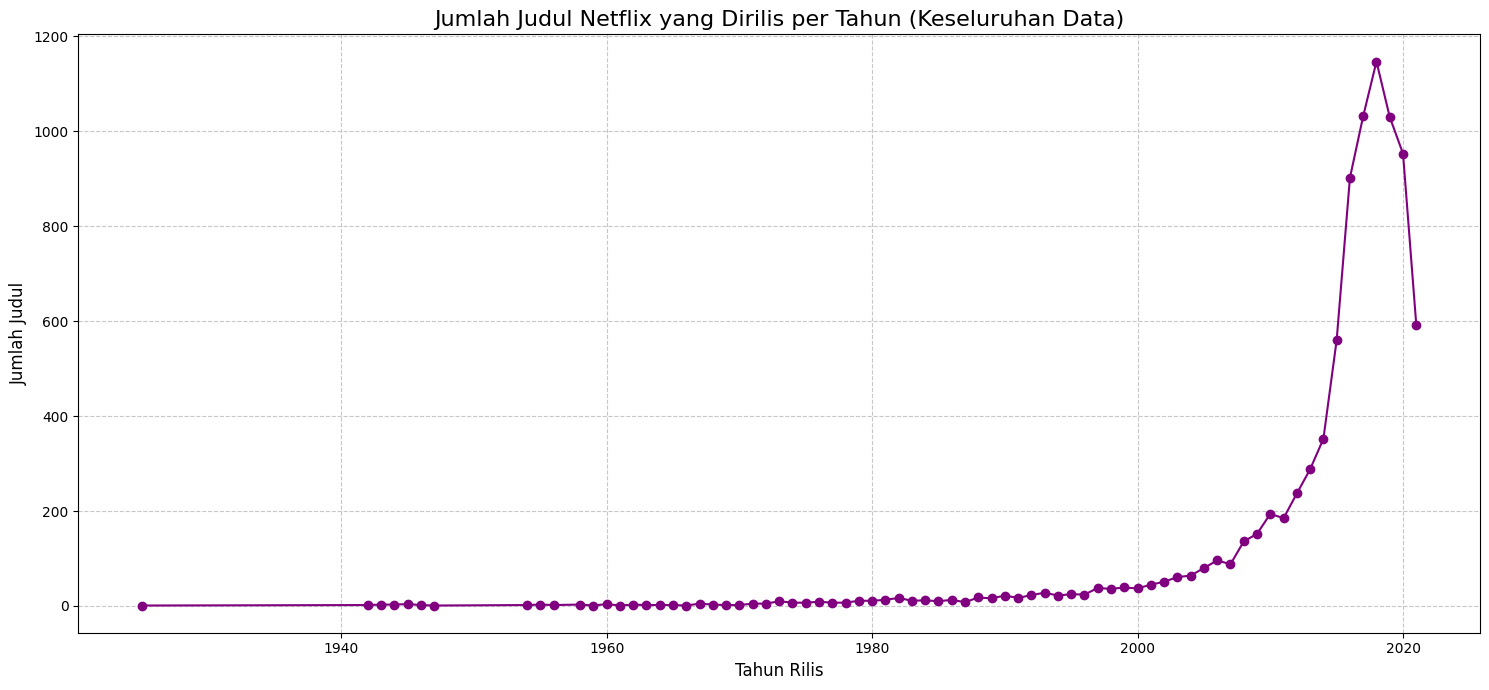

/tmp/ipython-input-43-4274234483.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis')


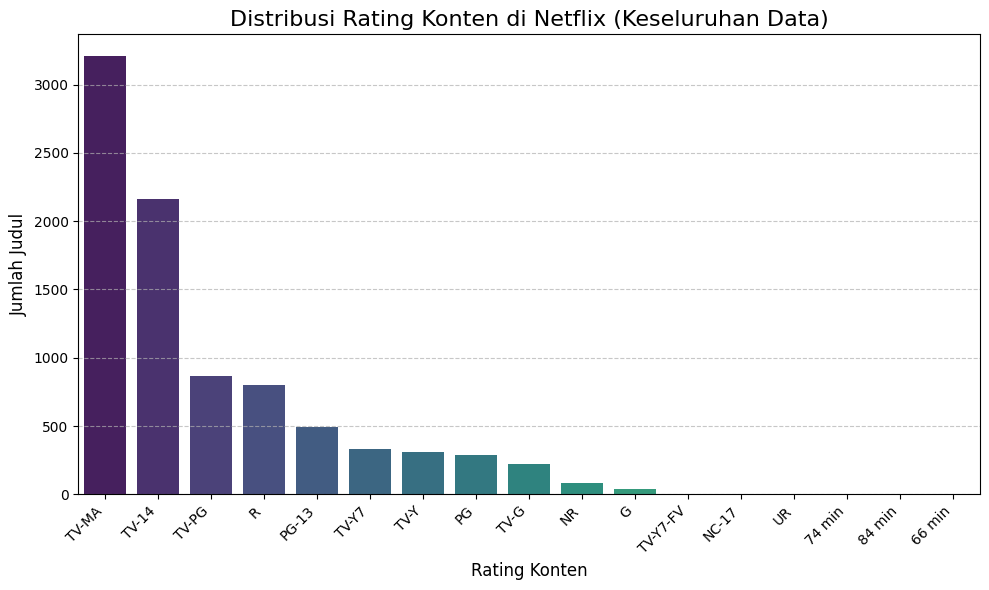

In [43]:
print("\n" + "="*70)
print("LANGKAH 1: EKSPLORASI DATA KESELURUHAN")
print("="*70)

# --- 1.1 Analisis Missing Values (Keseluruhan Dataset) ---
print("\n--- 1.1 Missing Values (Keseluruhan Dataset) ---")
print(df.isnull().sum())

# --- 1.2 Statistik Deskriptif ---
print("\n--- 1.2 Statistik Deskriptif ---")
print(df.describe(include='all')) # include='all' untuk menyertakan kolom non-numerik

# --- 1.3 Visualisasi Data Keseluruhan ---
print("\n--- 1.3 Visualisasi Data Keseluruhan ---")

# Visualisasi 1.3.1: Distribusi Tipe Konten (Film vs. Acara TV)
plt.figure(figsize=(8, 6))
df['type'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribusi Tipe Konten di Netflix (Keseluruhan Data)', fontsize=16)
plt.xlabel('Tipe Konten', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi 1.3.2: Popularitas Genre (Top 10 Genre Keseluruhan)
all_genres = df['listed_in'].dropna().str.split(', ').explode()
if not all_genres.empty:
    plt.figure(figsize=(12, 7))
    all_genres.value_counts().head(10).plot(kind='bar', color='lightgreen')
    plt.title('Top 10 Genre Paling Populer di Netflix (Keseluruhan Data)', fontsize=16)
    plt.xlabel('Genre', fontsize=12)
    plt.ylabel('Jumlah Judul', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada genre yang valid ditemukan di keseluruhan dataset.")

# Visualisasi 1.3.3: Pola Rilis Temporal (Jumlah Judul per Tahun Rilis Keseluruhan)
plt.figure(figsize=(15, 7))
df['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='purple')
plt.title('Jumlah Judul Netflix yang Dirilis per Tahun (Keseluruhan Data)', fontsize=16)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi 1.3.4: Distribusi Rating Konten (Keseluruhan)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis')
plt.title('Distribusi Rating Konten di Netflix (Keseluruhan Data)', fontsize=16)
plt.xlabel('Rating Konten', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Langkah 2: Filtering Data Hollywood & Analisis Awal**

In [30]:
print("\n" + "="*70)
print("LANGKAH 2: FILTERING DATA HOLLYWOOD & ANALISIS AWAL")
print("="*70)

# --- 2.1 Filter Data Hollywood ---
print("\n--- 2.1 Memfilter Data Hollywood ---")
# Menghapus baris di mana 'country' kosong, lalu membuat salinan untuk menghindari SettingWithCopyWarning
df_filtered_for_hollywood = df.dropna(subset=['country']).copy()

# Mengubah kolom 'country' menjadi string untuk memastikan operasi str.contains() berjalan lancar
df_filtered_for_hollywood['country'] = df_filtered_for_hollywood['country'].astype(str)

# Filter film atau acara TV yang diproduksi di "United States" (dianggap Hollywood)
hollywood_content_df = df_filtered_for_hollywood[df_filtered_for_hollywood['country'].str.contains('United States', case=False, na=False)]

if hollywood_content_df.empty:
    print("Tidak ada konten Hollywood yang ditemukan setelah filter.")
    exit() # Hentikan eksekusi jika tidak ada data Hollywood

print(f"Jumlah judul konten Hollywood (film & TV Show) yang teridentifikasi: {len(hollywood_content_df)}")

# --- 2.2 Tampilan 5 Baris Pertama Konten Hollywood (untuk Laporan Bagian 2.4) ---
print("\n--- 2.2 Tampilan 5 Baris Pertama Konten Hollywood (untuk Laporan Bagian 2.4) ---")
print("Salin output di bawah ini ke laporan Anda:")
print(hollywood_content_df.head().to_markdown(index=False))


# --- 2.3 Analisis Missing Values di Dataset Hollywood ---
print("\n--- 2.3 Analisis Missing Values di Dataset Hollywood ---")
missing_values_hollywood = hollywood_content_df.isnull().sum()
total_rows_hollywood = len(hollywood_content_df)

for col, count in missing_values_hollywood.items():
    if count > 0:
        percentage = (count / total_rows_hollywood) * 100
        print(f"- {col}: {count} ({percentage:.2f}%)")
    else:
        print(f"- {col}: {count} (0.00%)")


BAGIAN 2: FILTERING DATA HOLLYWOOD & ANALISIS AWAL

--- 2.1 Memfilter Data Hollywood ---
Jumlah judul konten Hollywood (film & TV Show) yang teridentifikasi: 3690

--- 2.2 Tampilan 5 Baris Pertama Konten Hollywood (untuk Laporan Bagian 2.4) ---
Salin output di bawah ini ke laporan Anda:
| show_id   | type    | title                | director        | cast                                                                                                                                                                   | country                                                               | date_added         | date_added.1   |   release_year | rating   | duration   | listed_in                                        | description                                                                                                                                              |
|:----------|:--------|:---------------------|:----------------|:-------------------------------------------------------

**Langkah 3: Eksplorasi & Visualisasi Data Hollywood Spesifik**


LANGKAH 3: EKSPLORASI & VISUALISASI DATA HOLLYWOOD SPESIFIK

--- 3.1 Visualisasi Distribusi Tipe Konten Hollywood ---


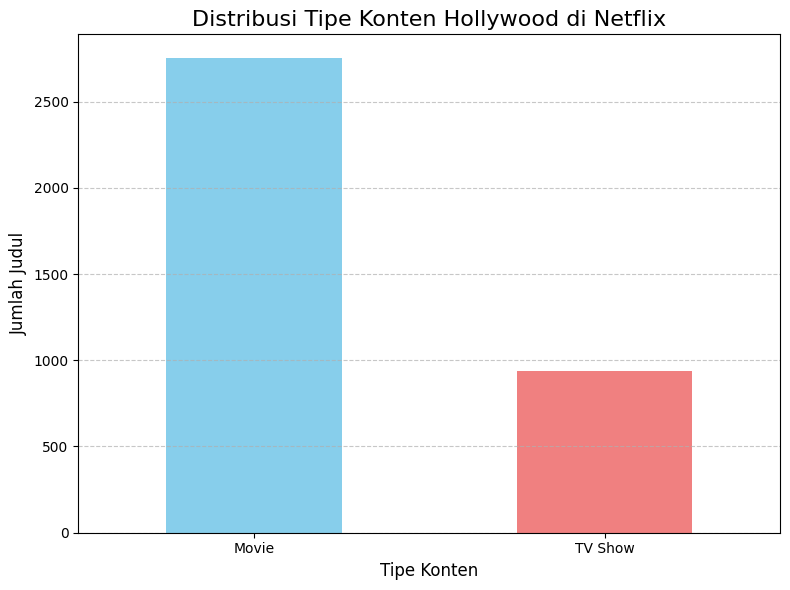

Gambar 1: Distribusi Tipe Konten Hollywood di Netflix

--- 3.2 Visualisasi Distribusi Rating Konten Hollywood ---


/tmp/ipython-input-44-1370869422.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hollywood_content_df, x='rating', order=hollywood_content_df['rating'].value_counts().index, palette='viridis')


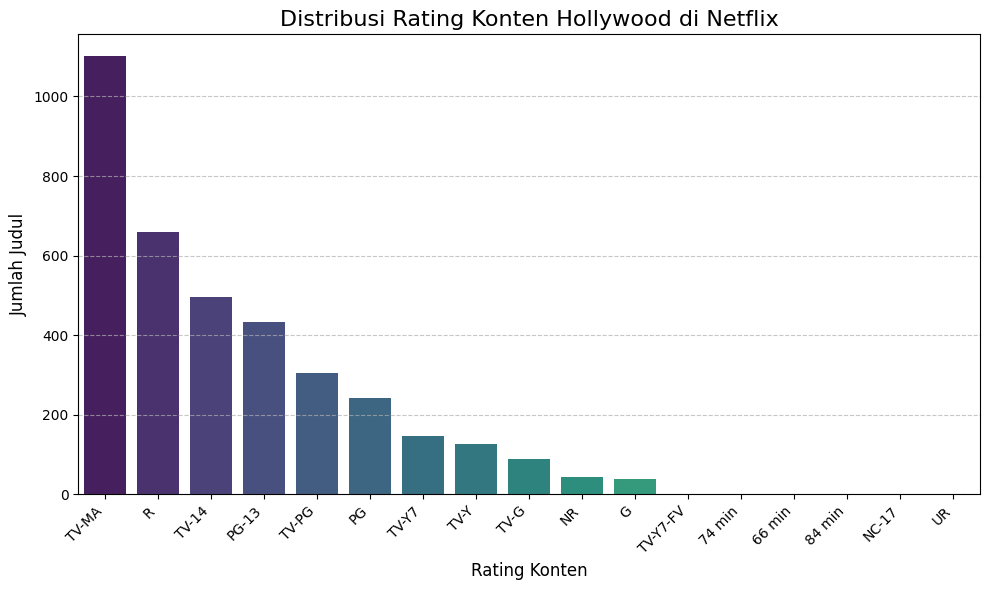

Gambar 2: Distribusi Rating Konten Hollywood di Netflix

--- 3.3 Visualisasi Pola Rilis Temporal Konten Hollywood ---


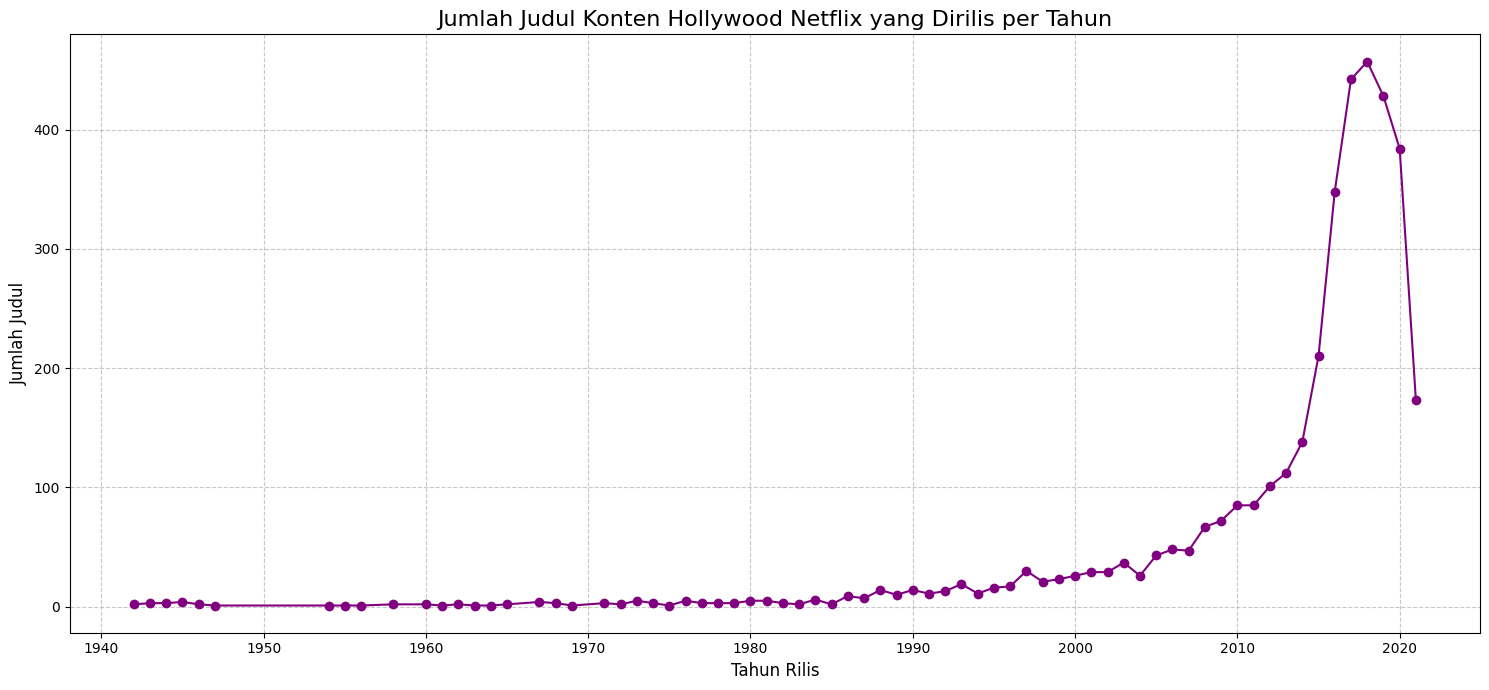

Gambar 3: Jumlah Judul Konten Hollywood Netflix yang Dirilis per Tahun

--- 3.4 Visualisasi Popularitas Genre Hollywood ---


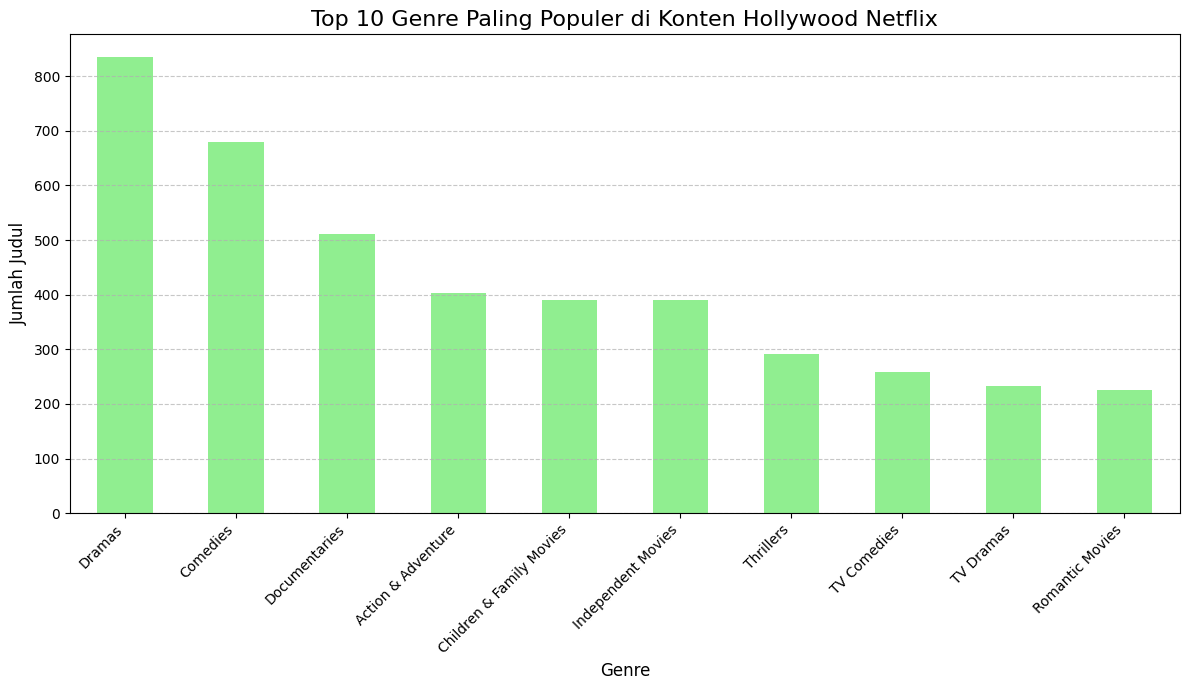

Gambar 4: Top 10 Genre Paling Populer di Konten Hollywood Netflix


In [44]:
print("\n" + "="*70)
print("LANGKAH 3: EKSPLORASI & VISUALISASI DATA HOLLYWOOD SPESIFIK")
print("="*70)

# --- 3.1 Visualisasi Distribusi Tipe Konten Hollywood (Gambar 1 Laporan) ---
print("\n--- 3.1 Visualisasi Distribusi Tipe Konten Hollywood ---") # Ditambahkan
plt.figure(figsize=(8, 6))
hollywood_content_df['type'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribusi Tipe Konten Hollywood di Netflix', fontsize=16)
plt.xlabel('Tipe Konten', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Gambar 1: Distribusi Tipe Konten Hollywood di Netflix")


# --- 3.2 Visualisasi Distribusi Rating Konten Hollywood (Gambar 2 Laporan) ---
print("\n--- 3.2 Visualisasi Distribusi Rating Konten Hollywood ---") # Ditambahkan
plt.figure(figsize=(10, 6))
sns.countplot(data=hollywood_content_df, x='rating', order=hollywood_content_df['rating'].value_counts().index, palette='viridis')
plt.title('Distribusi Rating Konten Hollywood di Netflix', fontsize=16)
plt.xlabel('Rating Konten', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Gambar 2: Distribusi Rating Konten Hollywood di Netflix")


# --- 3.3 Visualisasi Pola Rilis Temporal Konten Hollywood (Gambar 3 Laporan) ---
print("\n--- 3.3 Visualisasi Pola Rilis Temporal Konten Hollywood ---") # Ditambahkan
plt.figure(figsize=(15, 7))
hollywood_content_df['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='purple')
plt.title('Jumlah Judul Konten Hollywood Netflix yang Dirilis per Tahun', fontsize=16)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Gambar 3: Jumlah Judul Konten Hollywood Netflix yang Dirilis per Tahun")


# --- 3.4 Visualisasi Popularitas Genre Hollywood (Gambar 4 Laporan) ---
print("\n--- 3.4 Visualisasi Popularitas Genre Hollywood ---") # Ditambahkan
hollywood_genres = hollywood_content_df['listed_in'].dropna().str.split(', ').explode()
if not hollywood_genres.empty:
    plt.figure(figsize=(12, 7))
    hollywood_genres.value_counts().head(10).plot(kind='bar', color='lightgreen')
    plt.title('Top 10 Genre Paling Populer di Konten Hollywood Netflix', fontsize=16)
    plt.xlabel('Genre', fontsize=12)
    plt.ylabel('Jumlah Judul', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("Gambar 4: Top 10 Genre Paling Populer di Konten Hollywood Netflix")
else:
    print("Tidak ada genre yang valid ditemukan untuk konten Hollywood setelah pembersihan.")

**Langkah 4: PRA-PEMROSESAN LANJUTAN Untuk Model Algoritma DECISION TREE**

Persiapan data lebih lanjut (imputasi, encoding, scaling) sebelum pelatihan model.

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
# from sklearn.decomposition import PCA # PCA tidak digunakan di blok ini, jadi bisa dihilangkan importnya jika hanya fokus pada blok ini
# from google.colab import files, drive # Imports ini diasumsikan sudah ada di awal notebook

# Asumsi: df dan hollywood_content_df sudah ada dan terisi dari bagian-bagian sebelumnya.
# Jika Anda menjalankan blok ini secara terpisah, Anda perlu memastikan df dan hollywood_content_df didefinisikan.
# Contoh singkat definisi df dan hollywood_content_df untuk pengujian blok ini secara mandiri:
# df = pd.DataFrame({'country': ['United States', 'Canada', 'United States', np.nan],
#                    'duration': ['90 min', '4 Seasons', '120 min', '1 Season'],
#                    'rating': ['PG-13', 'TV-MA', 'R', 'TV-G'],
#                    'release_year': [2020, 2021, 2019, 2022],
#                    'type': ['Movie', 'TV Show', 'Movie', 'TV Show'],
#                    'title': ['Film A', 'Show B', 'Film C', 'Show D'],
#                    'date_added': ['Sept 1', 'Sept 2', 'Sept 3', 'Sept 4'],
#                    'date_added.1': ['01-09-2021', '02-09-2021', '03-09-2021', '04-09-2021'],
#                    'listed_in': ['Comedies', 'Dramas', 'Action', 'Kids'],
#                    'description': ['Desc A', 'Desc B', 'Desc C', 'Desc D']})
# df_filtered_for_hollywood = df.dropna(subset=['country']).copy()
# df_filtered_for_hollywood['country'] = df_filtered_for_hollywood['country'].astype(str)
# hollywood_content_df = df_filtered_for_hollywood[df_filtered_for_hollywood['country'].str.contains('United States', case=False, na=False)]


print("\n" + "="*70)
print("LANGKAH 4: PRA-PEMROSESAN LANJUTAN UNTUK MODEL ALGORITMA DECISION TREE")
print("="*70)

# Salin DataFrame untuk pra-pemrosesan model agar tidak mengganggu df asli
hollywood_df_for_model = hollywood_content_df.copy()

# --- 4.1 Penanganan Missing Values pada Fitur Model ---
print("\n--- 4.1 Penanganan Missing Values pada Fitur Model ---") # Ditambahkan
# Ekstraksi durasi numerik dari kolom 'duration'
hollywood_df_for_model['duration_numeric'] = hollywood_df_for_model['duration'].str.extract('(\d+)').astype(float)
# Mengisi NaN yang mungkin muncul setelah ekstraksi (misal '4 Seasons') dengan median
hollywood_df_for_model['duration_numeric'] = hollywood_df_for_model['duration_numeric'].fillna(hollywood_df_for_model['duration_numeric'].median())

# Tangani NaN di 'rating' sebelum encoding (jika ada, meskipun sebelumnya 0.00%)
# Ini memastikan LabelEncoder tidak error jika ada NaN
hollywood_df_for_model['rating'] = hollywood_df_for_model['rating'].fillna('Unknown')
print("Kolom 'duration_numeric' dibuat dan NaN diisi dengan median. Kolom 'rating' diisi 'Unknown' jika ada NaN.")


# --- 4.2 Encoding Variabel Kategorikal ---
print("\n--- 4.2 Encoding Variabel Kategorikal ---") # Ditambahkan
le_rating = LabelEncoder()
hollywood_df_for_model['rating_encoded'] = le_rating.fit_transform(hollywood_df_for_model['rating'])
print(f"\nMapping Rating yang dipelajari: {list(zip(le_rating.classes_, le_rating.transform(le_rating.classes_)))}")

le_type = LabelEncoder()
hollywood_df_for_model['type_encoded'] = le_type.fit_transform(hollywood_df_for_model['type'])
print(f"Mapping Tipe Konten: {list(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")
print("Kolom 'rating' dan 'type' berhasil di-encode.")


# --- 4.3 Tampilan 5 Baris Data Setelah Pra-pemrosesan Awal (untuk Laporan Bagian 3.6) ---
print("\n--- 4.3 Tampilan 5 Baris Data Setelah Pra-pemrosesan Awal (untuk Laporan Bagian 3.6) ---") # Ditambahkan
display_cols = ['title', 'type', 'release_year', 'rating', 'rating_encoded', 'duration', 'duration_numeric', 'listed_in']
print("Salin output di bawah ini ke laporan Anda:")
# Pastikan display_cols ada di hollywood_df_for_model
valid_display_cols = [col for col in display_cols if col in hollywood_df_for_model.columns]
print(hollywood_df_for_model[valid_display_cols].head().to_markdown(index=False))
print("Tampilan awal DataFrame setelah pra-pemrosesan awal ditampilkan.")


# --- 4.4 Pemilihan Fitur dan Variabel Target ---
print("\n--- 4.4 Pemilihan Fitur dan Variabel Target ---") # Ditambahkan
features_for_model = ['release_year', 'rating_encoded', 'duration_numeric']
target_column = 'type_encoded'

# Menghapus baris yang mungkin masih memiliki NaN di fitur yang dipilih setelah semua pra-pemrosesan
# Menggunakan .copy() lagi untuk df_model_ready agar benar-benar independen
df_model_ready = hollywood_df_for_model[features_for_model + [target_column]].dropna().copy()

if df_model_ready.empty:
    print("DataFrame kosong setelah pembersihan NaN pada fitur yang dipilih untuk model. Tidak dapat melatih model.")
    exit()

# Ambil X dan y sebagai salinan terpisah
X = df_model_ready[features_for_model].copy()
y = df_model_ready[target_column].copy()
print(f"Fitur ({features_for_model}) dan target ({target_column}) telah dipilih.")


# --- 4.5 Normalisasi Fitur Numerik (Opsional, tapi direkomendasikan untuk beberapa model) ---
print("\n--- 4.5 Normalisasi Fitur Numerik ---") # Ditambahkan
scaler = MinMaxScaler()
# Lakukan scaling langsung pada X (yang sudah menjadi salinan)
X[features_for_model] = scaler.fit_transform(X[features_for_model])
print("Fitur numerik (release_year, duration_numeric) berhasil dinormalisasi.")


# --- 4.6 Pembagian Data (Training dan Testing Set) ---
print("\n--- 4.6 Pembagian Data (Training dan Testing Set) ---") # Ditambahkan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Ukuran training set: {len(X_train)} | Ukuran testing set: {len(X_test)}")
print("Data berhasil dibagi menjadi training dan testing set.")


LANGKAH 4: PRA-PEMROSESAN LANJUTAN UNTUK MODEL ALGORITMA DECISION TREE

--- 4.1 Penanganan Missing Values pada Fitur Model ---
Kolom 'duration_numeric' dibuat dan NaN diisi dengan median. Kolom 'rating' diisi 'Unknown' jika ada NaN.

--- 4.2 Encoding Variabel Kategorikal ---

Mapping Rating yang dipelajari: [('66 min', np.int64(0)), ('74 min', np.int64(1)), ('84 min', np.int64(2)), ('G', np.int64(3)), ('NC-17', np.int64(4)), ('NR', np.int64(5)), ('PG', np.int64(6)), ('PG-13', np.int64(7)), ('R', np.int64(8)), ('TV-14', np.int64(9)), ('TV-G', np.int64(10)), ('TV-MA', np.int64(11)), ('TV-PG', np.int64(12)), ('TV-Y', np.int64(13)), ('TV-Y7', np.int64(14)), ('TV-Y7-FV', np.int64(15)), ('UR', np.int64(16))]
Mapping Tipe Konten: [('Movie', np.int64(0)), ('TV Show', np.int64(1))]
Kolom 'rating' dan 'type' berhasil di-encode.

--- 4.3 Tampilan 5 Baris Data Setelah Pra-pemrosesan Awal (untuk Laporan Bagian 3.6) ---
Salin output di bawah ini ke laporan Anda:
| title                | type    |  

**Langkah 5: PEMBANGUNAN & EVALUASI MODEL Algoritma DECISION TREE**

In [47]:
print("\n" + "="*70)
print("LANGKAH 5: PEMBANGUNAN & EVALUASI MODEL ALGORITMA DECISION TREE")
print("="*70)

# --- 5.1 Pelatihan Model Decision Tree ---
print("\n--- 5.1 Pelatihan Model Decision Tree ---") # Baris ini yang perlu ditambahkan
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5) # max_depth=5 untuk kesederhanaan
model_dt.fit(X_train, y_train)
print("\nModel Decision Tree berhasil dilatih.")

# --- 5.2 Evaluasi Model ---
print("\n--- 5.2 Evaluasi Model Decision Tree ---")
y_pred = model_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le_type.classes_, zero_division=0)

print(f"Akurasi Model Decision Tree: {accuracy:.4f}") # Tampilkan 4 angka di belakang koma
print("\nClassification Report:\n", report)

# --- 5.3 Pentingnya Fitur (Feature Importance) ---
print("\n--- 5.3 Pentingnya Fitur (Feature Importance) ---")
feature_importance = pd.Series(model_dt.feature_importances_, index=features_for_model).sort_values(ascending=False)
print(feature_importance)


LANGKAH 5: PEMBANGUNAN & EVALUASI MODEL ALGORITMA DECISION TREE

--- 5.1 Pelatihan Model Decision Tree ---

Model Decision Tree berhasil dilatih.

--- 5.2 Evaluasi Model Decision Tree ---
Akurasi Model Decision Tree: 1.0000

Classification Report:
               precision    recall  f1-score   support

       Movie       1.00      1.00      1.00       548
     TV Show       1.00      1.00      1.00       190

    accuracy                           1.00       738
   macro avg       1.00      1.00      1.00       738
weighted avg       1.00      1.00      1.00       738


--- 5.3 Pentingnya Fitur (Feature Importance) ---
duration_numeric    0.992983
rating_encoded      0.004282
release_year        0.002735
dtype: float64


**Langkah 6: PREDIKSI UNTUK TAHUN 2026**

Menggunakan model terlatih untuk membuat prediksi skenario di tahun 2026.

In [48]:
print("\n" + "="*70)
print("LANGKAH 6: PREDIKSI UNTUK TAHUN 2026")
print("="*70)

# Menghitung median durasi dari data Hollywood yang bersih
# Hitung median durasi untuk Movie (dalam menit)
avg_movie_duration = hollywood_df_for_model[hollywood_df_for_model['type'] == 'Movie']['duration_numeric'].median()

# Hitung median durasi untuk TV Show (dalam musim)
# Tidak perlu asumsi menit/episode di sini, biarkan sebagai jumlah musim
avg_tvshow_duration = hollywood_df_for_model[hollywood_df_for_model['type'] == 'TV Show']['duration_numeric'].median()

print(f"\nMedian Durasi Film Hollywood: {avg_movie_duration:.0f} menit")
print(f"Median Durasi TV Show Hollywood: {avg_tvshow_duration:.0f} musim") # Pesan lebih realistis

# Definisi rating umum yang akan digunakan untuk skenario prediksi
common_ratings_for_prediction = ['TV-MA', 'R', 'PG-13', 'TV-G', 'TV-14']
encoded_ratings = {}
for r in common_ratings_for_prediction:
    if r in le_rating.classes_:
        encoded_ratings[r] = le_rating.transform([r])[0]
    else:
        print(f"Peringatan: Rating '{r}' tidak ditemukan dalam data historis. Akan dilewati untuk skenario.")

print("\n--- Skenario Prediksi untuk Tahun Rilis 2026 ---")

# Skenario 1: Film (durasi ~rata-rata movie) dengan rating TV-MA
if 'TV-MA' in encoded_ratings:
    input_data_1_df = pd.DataFrame([[2026, encoded_ratings['TV-MA'], avg_movie_duration]],
                                   columns=features_for_model)
    scaled_input_1_df = pd.DataFrame(scaler.transform(input_data_1_df), columns=features_for_model)
    predicted_type_1_encoded = model_dt.predict(scaled_input_1_df)
    predicted_type_1 = le_type.inverse_transform(predicted_type_1_encoded)[0]
    # Output disesuaikan untuk "menit"
    print(f"  Skenario 1 (Tahun 2026, Rating TV-MA, Durasi {int(avg_movie_duration)} menit): Diprediksi sebagai {predicted_type_1}")
else:
    print("  Skenario 1 dilewati: Rating 'TV-MA' tidak tersedia untuk encoding.")


# Skenario 2: TV Show (durasi ~rata-rata tv show) dengan rating TV-14
if 'TV-14' in encoded_ratings:
    input_data_2_df = pd.DataFrame([[2026, encoded_ratings['TV-14'], avg_tvshow_duration]],
                                   columns=features_for_model)
    scaled_input_2_df = pd.DataFrame(scaler.transform(input_data_2_df), columns=features_for_model)
    predicted_type_2_encoded = model_dt.predict(scaled_input_2_df)
    predicted_type_2 = le_type.inverse_transform(predicted_type_2_encoded)[0]
    # Output disesuaikan untuk "musim"
    print(f"  Skenario 2 (Tahun 2026, Rating TV-14, Durasi {int(avg_tvshow_duration)} musim): Diprediksi sebagai {predicted_type_2}")
else:
    print("  Skenario 2 dilewati: Rating 'TV-14' tidak tersedia untuk encoding.")


# Skenario 3: Film (durasi lebih pendek) dengan rating PG-13
if 'PG-13' in encoded_ratings:
    input_data_3_df = pd.DataFrame([[2026, encoded_ratings['PG-13'], 90]],
                                   columns=features_for_model)
    scaled_input_3_df = pd.DataFrame(scaler.transform(input_data_3_df), columns=features_for_model)
    predicted_type_3_encoded = model_dt.predict(scaled_input_3_df)
    predicted_type_3 = le_type.inverse_transform(predicted_type_3_encoded)[0]
    # Output disesuaikan untuk "menit"
    print(f"  Skenario 3 (Tahun 2026, Rating PG-13, Durasi 90 menit): Diprediksi sebagai {predicted_type_3}")
else:
    print("  Skenario 3 dilewati: Rating 'PG-13' tidak tersedia untuk encoding.")


LANGKAH 6: PREDIKSI UNTUK TAHUN 2026

Median Durasi Film Hollywood: 94 menit
Median Durasi TV Show Hollywood: 1 musim

--- Skenario Prediksi untuk Tahun Rilis 2026 ---
  Skenario 1 (Tahun 2026, Rating TV-MA, Durasi 94 menit): Diprediksi sebagai Movie
  Skenario 2 (Tahun 2026, Rating TV-14, Durasi 1 musim): Diprediksi sebagai TV Show
  Skenario 3 (Tahun 2026, Rating PG-13, Durasi 90 menit): Diprediksi sebagai Movie


**Langkah 7: VISUALISASI MODEL Algoritma DECISION TREE**


LANGKAH 7: VISUALISASI MODEL ALGORITMA DECISION TREE

--- 7.1 Visualisasi Pohon Keputusan (Gambar 5 Laporan) ---


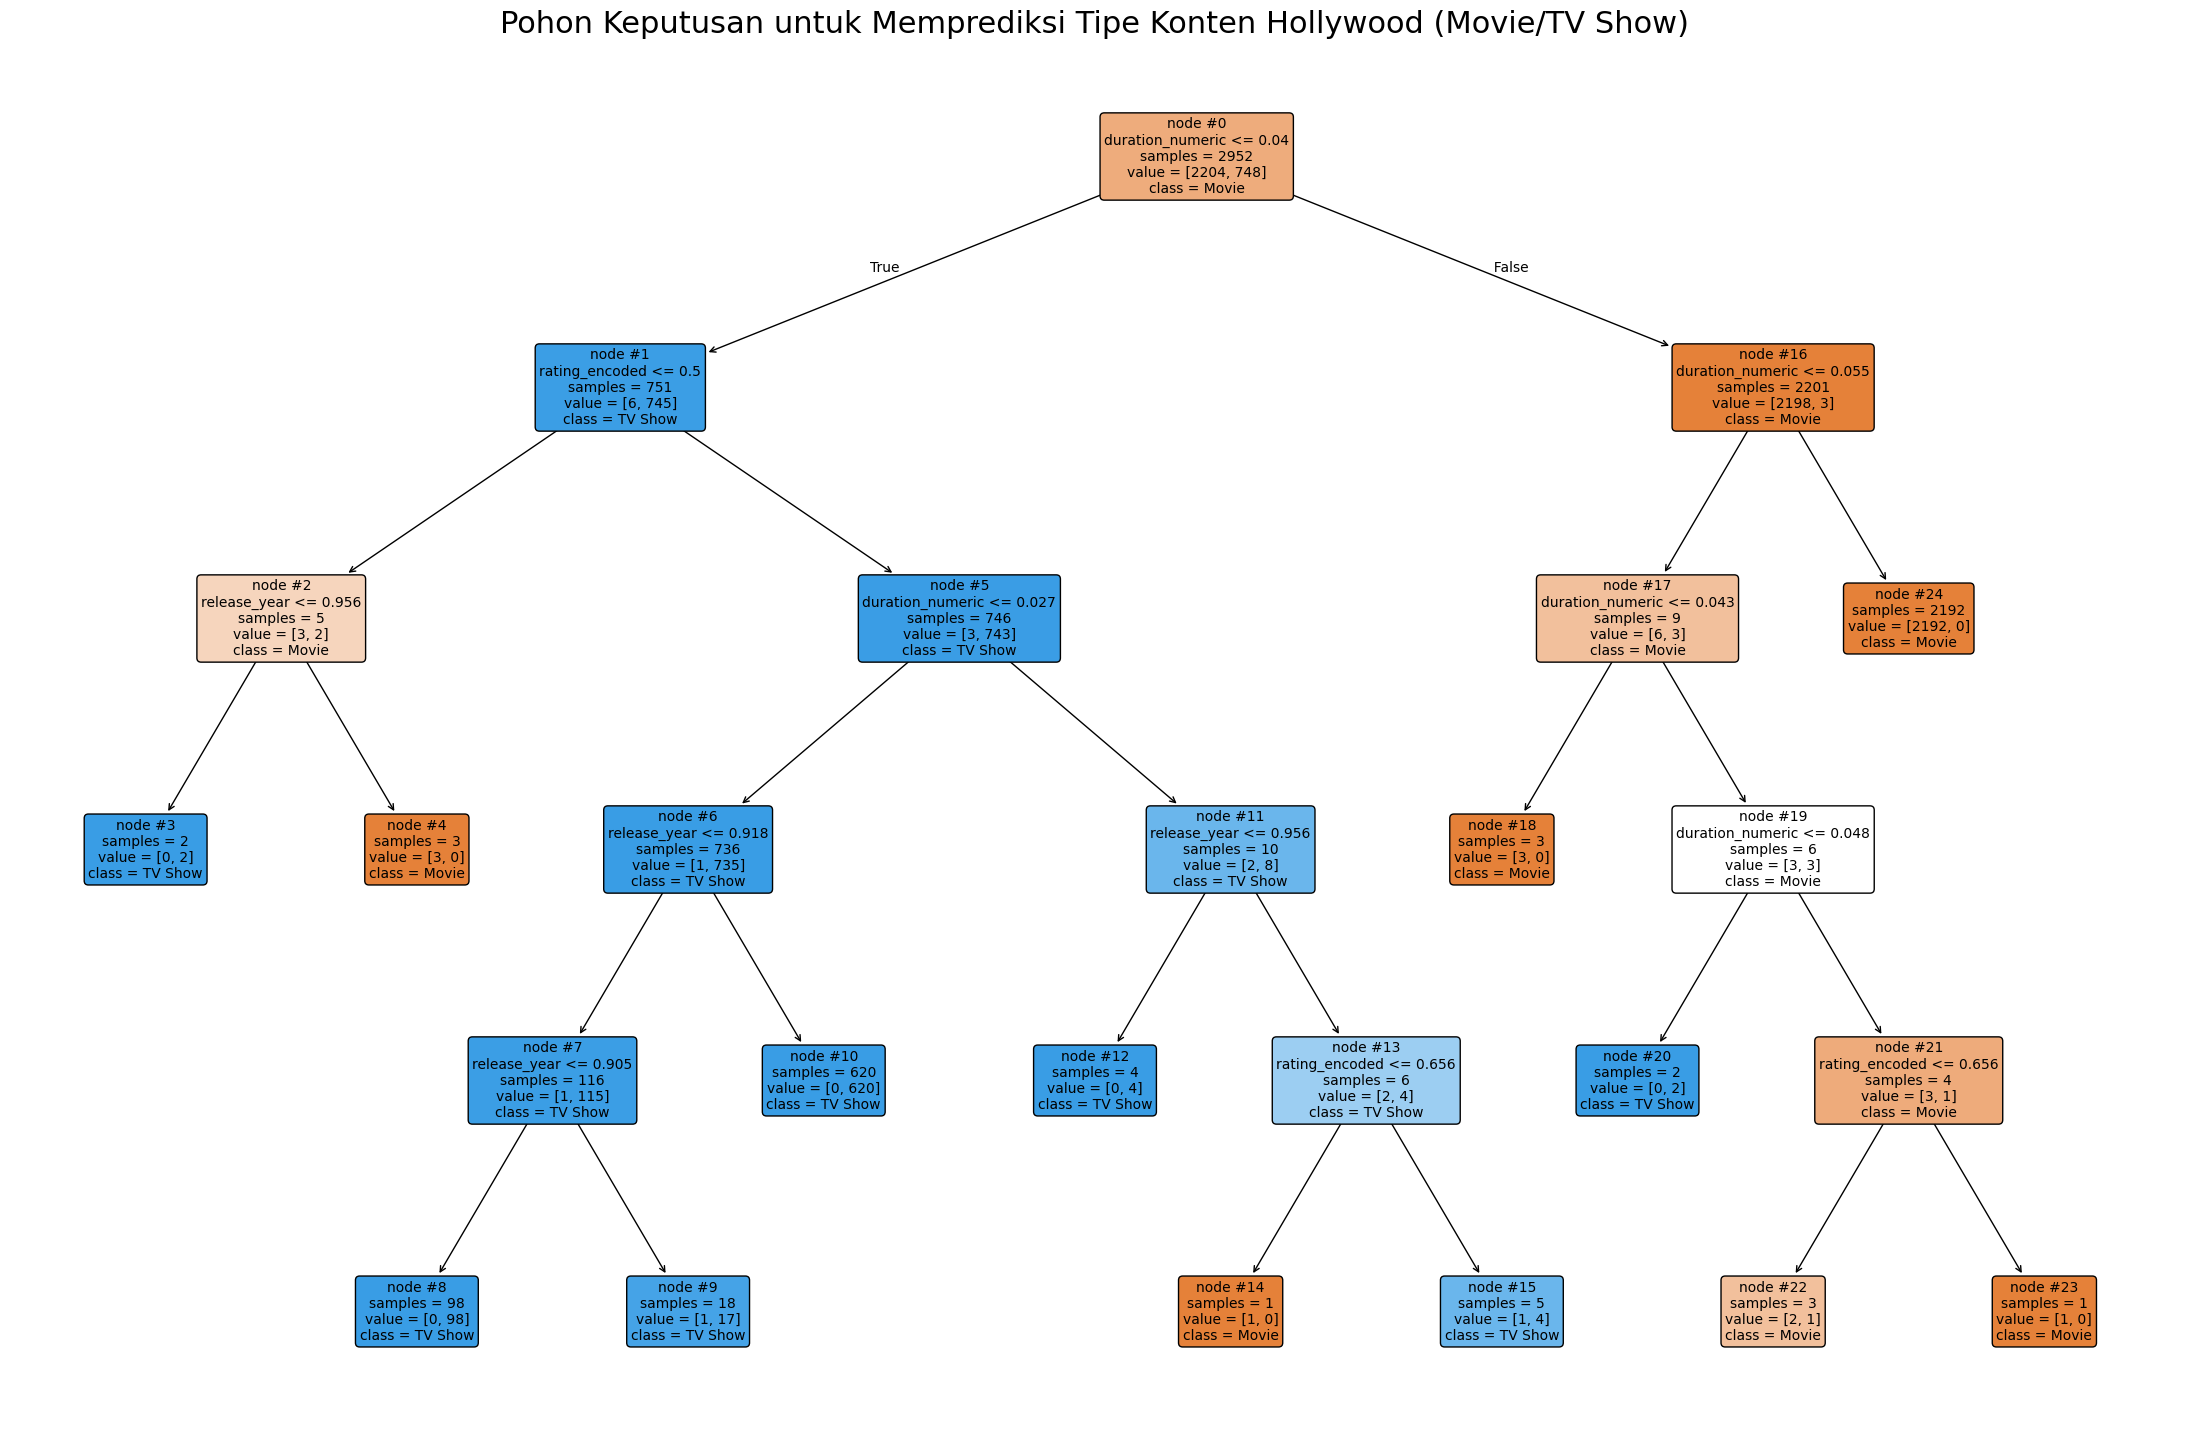

Gambar 5: Pohon Keputusan untuk Memprediksi Tipe Konten Hollywood (Movie/TV Show)

--- 7.2 Visualisasi Pentingnya Fitur (Feature Importance) (Gambar 6 Laporan) ---


/tmp/ipython-input-49-1793378225.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


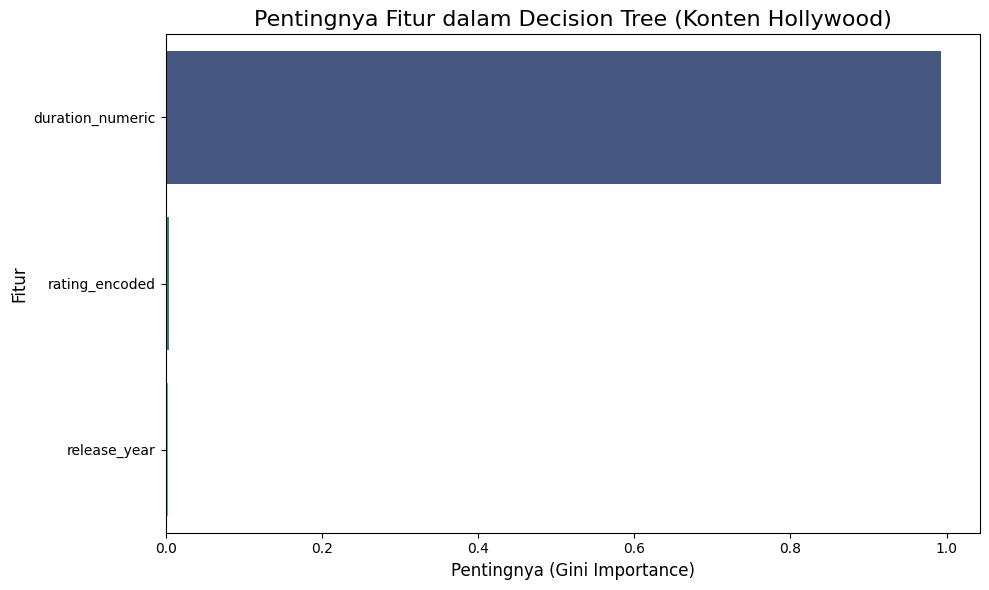

Gambar 6: Pentingnya Fitur dalam Decision Tree (Konten Hollywood)

--- 7.3 Visualisasi Distribusi Fitur Berdasarkan Tipe Konten (Gambar 7, 8, 9 Laporan) ---


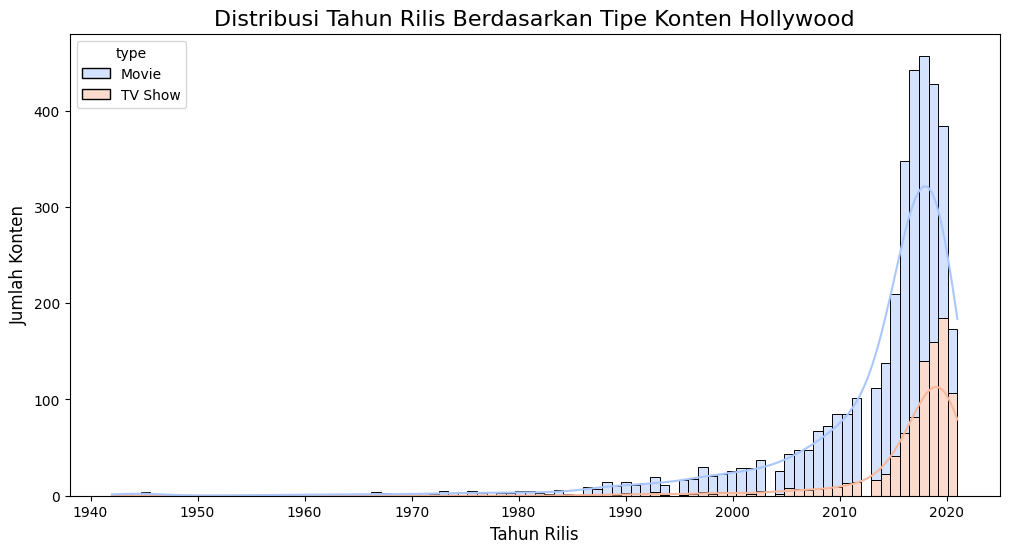

Gambar 7: Distribusi Tahun Rilis Berdasarkan Tipe Konten Hollywood


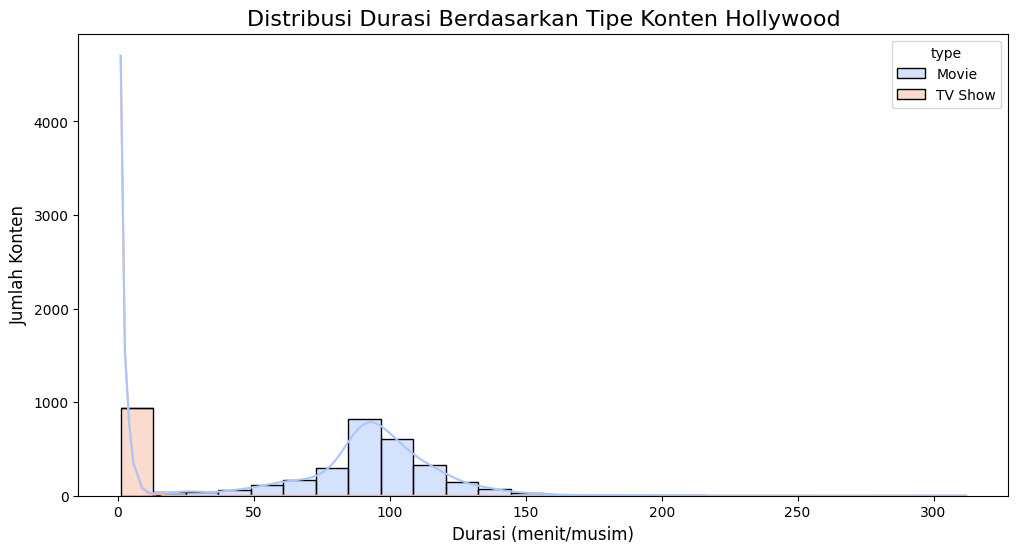

Gambar 8: Distribusi Durasi Berdasarkan Tipe Konten Hollywood


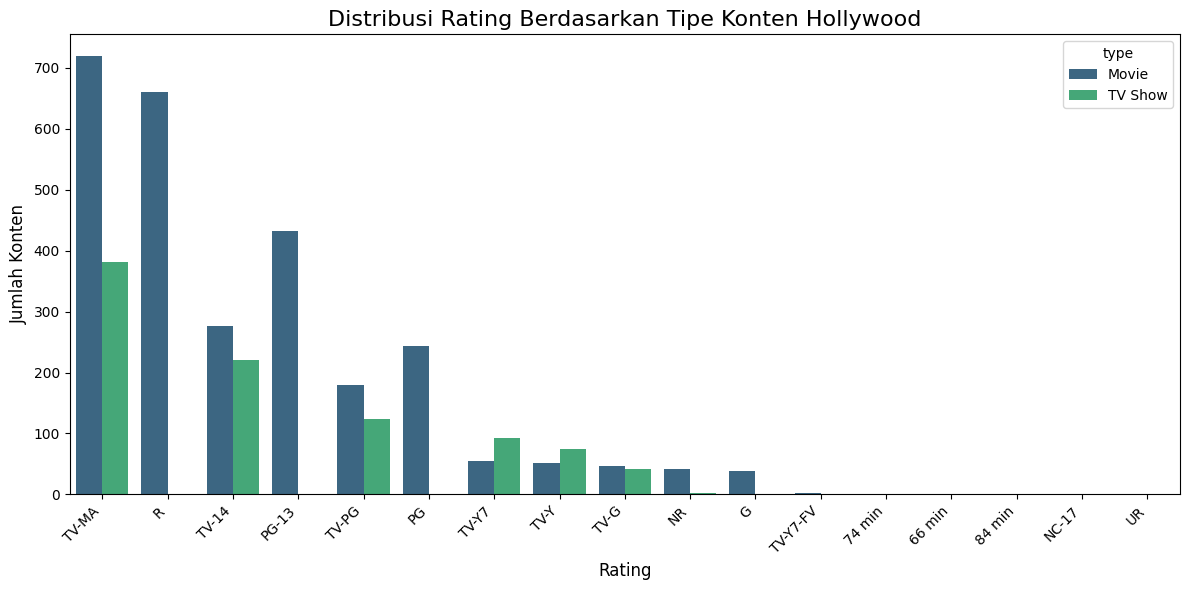

Gambar 9: Distribusi Rating Berdasarkan Tipe Konten Hollywood

SEMUA PROSES ANALISIS DAN PEMODELAN SELESAI


In [49]:
print("\n" + "="*70)
print("LANGKAH 7: VISUALISASI MODEL ALGORITMA DECISION TREE")
print("="*70)

# --- 7.1 Visualisasi Pohon Keputusan (Gambar 5 Laporan) ---
print("\n--- 7.1 Visualisasi Pohon Keputusan (Gambar 5 Laporan) ---")
plt.figure(figsize=(28, 18)) # Perbesar ukuran figure untuk visibilitas
plot_tree(model_dt,
          feature_names=features_for_model,
          class_names=le_type.classes_,
          filled=True,
          rounded=True,
          fontsize=10,
          impurity=False,
          node_ids=True,
          proportion=False
         )
plt.title('Pohon Keputusan untuk Memprediksi Tipe Konten Hollywood (Movie/TV Show)', fontsize=22)
plt.show()
print("Gambar 5: Pohon Keputusan untuk Memprediksi Tipe Konten Hollywood (Movie/TV Show)")

# --- 7.2 Visualisasi Pentingnya Fitur (Feature Importance) (Gambar 6 Laporan) ---
print("\n--- 7.2 Visualisasi Pentingnya Fitur (Feature Importance) (Gambar 6 Laporan) ---")
importance_df = pd.DataFrame({
    'Feature': features_for_model,
    'Importance': model_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Pentingnya Fitur dalam Decision Tree (Konten Hollywood)', fontsize=16)
plt.xlabel('Pentingnya (Gini Importance)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.tight_layout()
plt.show()
print("Gambar 6: Pentingnya Fitur dalam Decision Tree (Konten Hollywood)")


# --- 7.3 Visualisasi Distribusi Fitur Berdasarkan Tipe Konten (Gambar 7, 8, 9 Laporan) ---
print("\n--- 7.3 Visualisasi Distribusi Fitur Berdasarkan Tipe Konten (Gambar 7, 8, 9 Laporan) ---")

# Distribusi Release Year berdasarkan Tipe Konten (Gambar 7)
plt.figure(figsize=(12, 6))
sns.histplot(data=hollywood_df_for_model, x='release_year', hue='type', multiple='stack', kde=True, palette='coolwarm')
plt.title('Distribusi Tahun Rilis Berdasarkan Tipe Konten Hollywood', fontsize=16)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Jumlah Konten', fontsize=12)
plt.show()
print("Gambar 7: Distribusi Tahun Rilis Berdasarkan Tipe Konten Hollywood")


# Distribusi Duration Numeric berdasarkan Tipe Konten (Gambar 8)
plt.figure(figsize=(12, 6))
sns.histplot(data=hollywood_df_for_model, x='duration_numeric', hue='type', multiple='stack', kde=True, palette='coolwarm')
plt.title('Distribusi Durasi Berdasarkan Tipe Konten Hollywood', fontsize=16)
plt.xlabel('Durasi (menit/musim)', fontsize=12)
plt.ylabel('Jumlah Konten', fontsize=12)
plt.show()
print("Gambar 8: Distribusi Durasi Berdasarkan Tipe Konten Hollywood")


# Distribusi Rating (Categorical - Countplot) berdasarkan Tipe Konten (Gambar 9)
plt.figure(figsize=(12, 6))
sns.countplot(data=hollywood_df_for_model, x='rating', hue='type', palette='viridis', order=hollywood_df_for_model['rating'].value_counts().index)
plt.title('Distribusi Rating Berdasarkan Tipe Konten Hollywood', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Jumlah Konten', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Gambar 9: Distribusi Rating Berdasarkan Tipe Konten Hollywood")

print("\n" + "="*70)
print("SEMUA PROSES ANALISIS DAN PEMODELAN SELESAI")
print("="*70)